#### Section 1 — Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

#### Section 2 — Loading Dataset

In [2]:
fact_sales_df = pd.read_csv(
    r"C:\Data Analytics Projects\Cohort & Retention Analysis\Data\Cleaned\fact_sales.csv",
    parse_dates=[
        "purchase_datetime",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

#### Section 3 — Dataset Overview

In [3]:
fact_sales_df.shape

(110194, 18)

In [4]:
fact_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110194 entries, 0 to 110193
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110194 non-null  object        
 1   order_status                   110194 non-null  object        
 2   purchase_datetime              110194 non-null  datetime64[ns]
 3   order_approved_at              110179 non-null  datetime64[ns]
 4   order_delivered_carrier_date   110192 non-null  datetime64[ns]
 5   order_delivered_customer_date  110186 non-null  datetime64[ns]
 6   order_estimated_delivery_date  110194 non-null  datetime64[ns]
 7   customer_key                   110194 non-null  object        
 8   city                           110194 non-null  object        
 9   state                          110194 non-null  object        
 10  item_id                        110194 non-null  int64         
 11  

In [5]:
fact_sales_df.head()

,order_id,order_status,purchase_datetime,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_key,city,state,item_id,product_id,item_price,freight_value,product_category,total_payment,payment_installments,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,87285b34884572647811a353c7ac498a,29.99,8.72,Housewares,38.71,1.0,"credit_card, voucher"
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,Perfumery,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,159.90,19.22,Auto,179.12,3.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,Pet Shop,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,Stationery,28.62,1.0,credit_card


In [6]:
fact_sales_df.describe(include='all')

,order_id,order_status,purchase_datetime,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_key,city,state,item_id,product_id,item_price,freight_value,product_category,total_payment,payment_installments,payment_type
count,110194,110194,110194,110179,110192,110186,110194,110194,110194,110194,110194.000000,110194,110194.000000,110194.000000,110194,110194.000000,110194.000000,110194
unique,96477,1,NaN,NaN,NaN,NaN,NaN,93357,4085,27,NaN,32216,NaN,NaN,72,NaN,NaN,6
top,8272b63d03f5f79c56e9e4120aec44ef,delivered,NaN,NaN,NaN,NaN,NaN,c8460e4251689ba205045f3ea17884a1,sao paulo,SP,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,NaN,Bed Bath Table,NaN,NaN,credit_card
freq,21,110194,NaN,NaN,NaN,NaN,NaN,24,17400,46445,NaN,520,NaN,NaN,10953,NaN,NaN,82125
mean,NaN,NaN,2018-01-02 03:08:25.952538112,2018-01-02 14:42:35.646574848,2018-01-05 09:59:08.692863488,2018-01-14 14:16:29.175221760,2018-01-25 22:26:44.080076800,NaN,NaN,NaN,1.198160,NaN,119.982605,19.949064,NaN,179.466763,3.015373,NaN
min,NaN,NaN,2016-10-03 09:44:50,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-27 00:00:00,NaN,NaN,NaN,1.000000,NaN,0.850000,0.000000,NaN,9.590000,0.000000,NaN
25%,NaN,NaN,2017-09-15 07:43:45.500000,2017-09-15 15:07:55.500000,2017-09-18 22:32:11.500000,2017-09-26 20:18:28.750000128,2017-10-06 00:00:00,NaN,NaN,NaN,1.000000,NaN,39.900000,13.080000,NaN,65.600000,1.000000,NaN
50%,NaN,NaN,2018-01-21 10:14:11.500000,2018-01-22 13:57:26,2018-01-24 18:56:49.500000,2018-02-02 21:08:39,2018-02-16 00:00:00,NaN,NaN,NaN,1.000000,NaN,74.900000,16.260000,NaN,114.345000,2.000000,NaN
75%,NaN,NaN,2018-05-05 16:05:17.750000128,2018-05-05 23:10:41,2018-05-08 14:21:00,2018-05-15 20:15:15.750000128,2018-05-28 00:00:00,NaN,NaN,NaN,1.000000,NaN,134.192500,21.150000,NaN,194.960000,4.000000,NaN
max,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,NaN,NaN,NaN,21.000000,NaN,6735.000000,409.680000,NaN,13664.080000,24.000000,NaN


#### Section 4 — Business KPIs Calculation

In [7]:
total_orders = fact_sales_df['order_id'].nunique()

total_customers = fact_sales_df['customer_key'].nunique()

total_revenue = (
    fact_sales_df
    .groupby('order_id')['total_payment']
    .first()
    .sum()
)

total_products = fact_sales_df['product_id'].nunique()

avg_order_value = (
    fact_sales_df
    .groupby('order_id')['total_payment']
    .first()
    .mean()
)

print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Total Revenue     : ${total_revenue:,.2f}")
print(f"Total Products    : {total_products:,}")
print(f"Average Order Value : ${avg_order_value:,.2f}")

Total Orders      : 96,477
Total Customers   : 93,357
Total Revenue     : $15,422,461.77
Total Products    : 32,216
Average Order Value : $159.86


In [8]:
kpis = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Total Customers',
        'Total Revenue',
        'Total Products',
        'Average Order Value'
    ],
    'Value': [
        total_orders,
        total_customers,
        round(total_revenue, 2),
        total_products,
        round(avg_order_value, 2)
    ]
})

kpis

,Metric,Value
0,Total Orders,96477.00
1,Total Customers,93357.00
2,Total Revenue,15422461.77
3,Total Products,32216.00
4,Average Order Value,159.86


##### Business Insight
The platform processed nearly **96.5k** delivered orders from over **93k** unique customers, generating approximately **$15.8M** in revenue. The catalog contains more than **32k** unique products, and customers spend an average of **160** per order. The close relationship between the number of customers and orders suggests that repeat purchasing exists but may be relatively limited, highlighting the importance of cohort retention analysis to understand long-term customer behavior.

#### Section 5 — Sales Trend Over Time Analysis
How has Business performed over time in terms of Order Volumne and Revenue?

In [9]:
monthly_sales = (
    fact_sales_df
    .groupby('order_id')
    .agg({
        'purchase_datetime': 'first',
        'total_payment': 'first'
    })
    .reset_index()
)

monthly_sales['purchase_month'] = (
    monthly_sales['purchase_datetime']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_sales = (
    monthly_sales
    .groupby('purchase_month')
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('total_payment', 'sum')
    )
    .reset_index()
)

monthly_sales

,purchase_month,total_orders,total_revenue
0,2016-10-01,265,46566.71
1,2016-12-01,1,19.62
2,2017-01-01,750,127545.67
3,2017-02-01,1653,271298.65
4,2017-03-01,2546,414369.39
5,2017-04-01,2303,390952.18
6,2017-05-01,3546,567066.73
7,2017-06-01,3135,490225.60
8,2017-07-01,3872,566403.93
9,2017-08-01,4193,646000.61


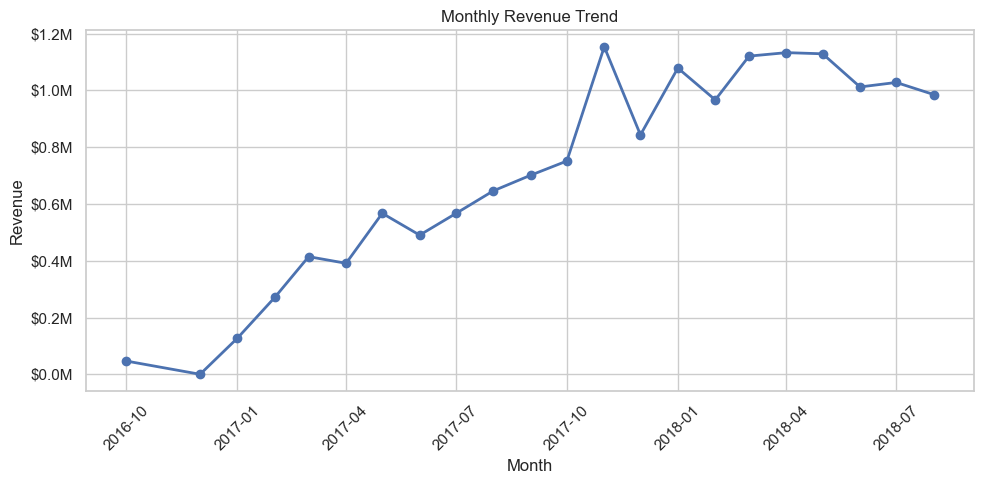

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['purchase_month'],
    monthly_sales['total_revenue'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

from matplotlib.ticker import FuncFormatter

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

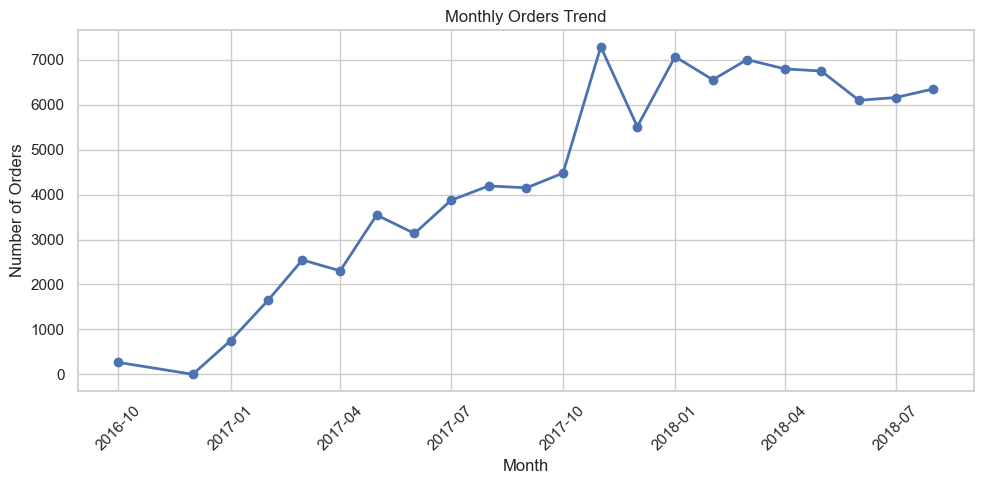

In [11]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['purchase_month'],
    monthly_sales['total_orders'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Business Insight
The monthly sales analysis reveals strong business growth throughout **2017**, with both revenue and order volumes increasing consistently. A significant peak is observed in **November 2017**, likely driven by seasonal shopping events. During 2018, sales performance stabilized, suggesting the marketplace had reached a more mature growth stage. Revenue and order trends closely mirror one another, indicating that revenue growth was primarily driven by increased purchasing activity rather than changes in average order value.

#### Section 6 — Product Category Performance
Which product categories contribute the most to the business in terms of order volume and revenue?

In [12]:
category_summary = (
    fact_sales_df
    .groupby('product_category')
    .agg(
        items_sold=('product_id', 'count'),
        revenue=('item_price', 'sum'),
        avg_item_price=('item_price', 'mean')
    )
    .sort_values('revenue', ascending=False)
)

category_summary.head(10)

,items_sold,revenue,avg_item_price
product_category,,,
Health Beauty,9462,1232996.75,130.310373
Watches Gifts,5859,1166176.98,199.040276
Bed Bath Table,10953,1023434.76,93.438762
Sports Leisure,8431,954852.55,113.254958
Computers Accessories,7644,888724.61,116.264339
Furniture Decor,8160,711927.69,87.246040
Housewares,6795,615628.69,90.600249
Cool Stuff,3718,610204.10,164.121598
Auto,4140,578966.65,139.847017


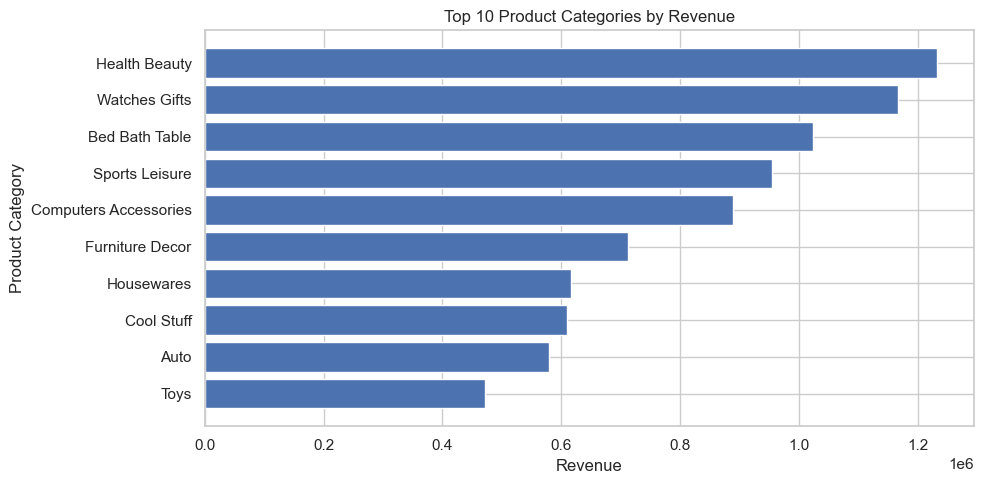

In [13]:
top_categories = category_summary.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_categories.index,
    top_categories['revenue']
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

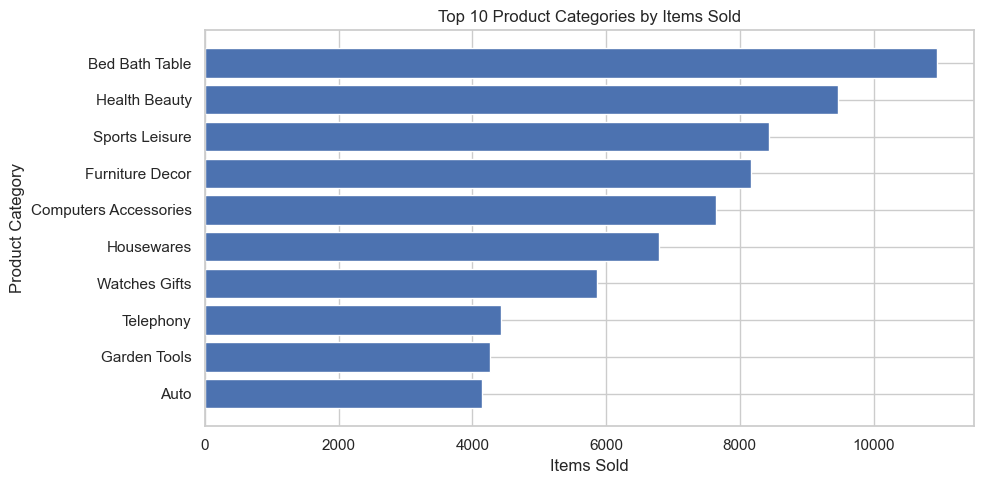

In [14]:
top_items = (
    category_summary
    .sort_values('items_sold', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top_items.index,
    top_items['items_sold']
)

plt.title('Top 10 Product Categories by Items Sold')
plt.xlabel('Items Sold')
plt.ylabel('Product Category')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##### Business Insights
1. **Health Beauty** is one of the marketplace's strongest categories, ranking highly in both revenue and sales volume.
2. **Bed Bath Table** records the highest number of items sold, indicating that it is one of the marketplace's most frequently purchased categories.
3. **Watches Gifts** generates exceptionally high revenue despite selling fewer items than several other categories. This indicates a higher average selling price and suggests the category contributes disproportionately to total revenue.

#### Section 7 — Geographic Analysis (State-wise Performance)
Which states generate the highest number of orders and revenue?

In [15]:
state_summary = (
    fact_sales_df
    .groupby('state')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_customers=('customer_key', 'nunique'),
        total_revenue=('item_price', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
)

state_summary.head(10)

,total_orders,total_customers,total_revenue
state,,,
SP,40500,39155,5067498.19
RJ,12350,11917,1759651.13
MG,11354,11001,1552481.83
RS,5345,5168,728897.47
PR,4923,4769,666063.51
SC,3546,3449,507012.13
BA,3256,3158,493584.14
DF,2080,2019,296498.41
GO,1957,1895,282836.70


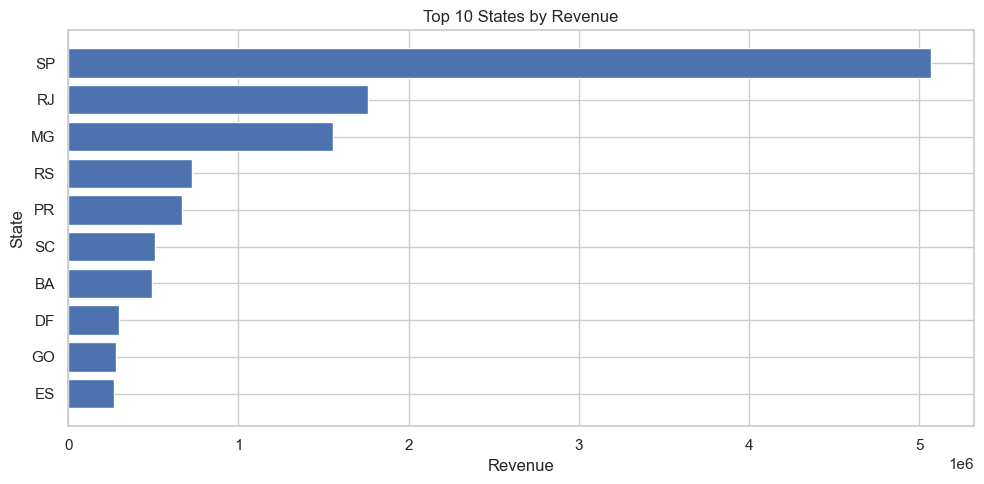

In [16]:
top_states_revenue = state_summary.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_states_revenue.index,
    top_states_revenue['total_revenue']
)

plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue')
plt.ylabel('State')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

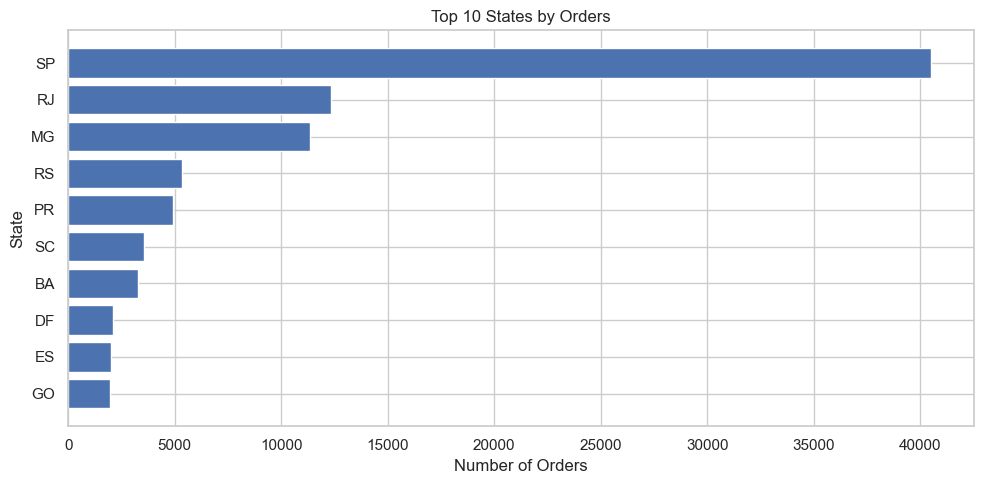

In [17]:
top_states_orders = (
    state_summary
    .sort_values('total_orders', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top_states_orders.index,
    top_states_orders['total_orders']
)

plt.title('Top 10 States by Orders')
plt.xlabel('Number of Orders')
plt.ylabel('State')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##### Business Insights
1. **São Paulo** is the company's primary revenue driver and largest customer market. Any changes in customer behavior within SP will have the greatest impact on overall business performance.
2. Business growth appears to be **volume-driven** due to parallel flow between revenue and orders.

#### Section 8 — Customer Purchase Frequency
How many customers buy only once, and how many return to purchase again?

In [18]:
customer_orders = (
    fact_sales_df
    .groupby('customer_key')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_spent=('item_price', 'sum')
    )
)

customer_orders.head()

,total_orders,total_spent
customer_key,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90
0000f46a3911fa3c0805444483337064,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,1,25.99
0004aac84e0df4da2b147fca70cf8255,1,180.00


In [19]:
customer_orders.describe()

,total_orders,total_spent
count,93357.000000,93357.000000
mean,1.033420,141.621551
std,0.209099,215.695168
min,1.000000,0.850000
25%,1.000000,47.650000
50%,1.000000,89.700000
75%,1.000000,154.750000
max,15.000000,13440.000000


In [20]:
purchase_frequency = (
    customer_orders['total_orders']
    .value_counts()
    .sort_index()
)

purchase_frequency

total_orders
1     90556
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [21]:
purchase_frequency_pct = round(
    purchase_frequency / purchase_frequency.sum() * 100,
    2
)

purchase_frequency_pct

total_orders
1     97.00
2      2.76
3      0.19
4      0.03
5      0.01
6      0.01
7      0.00
9      0.00
15     0.00
Name: count, dtype: float64

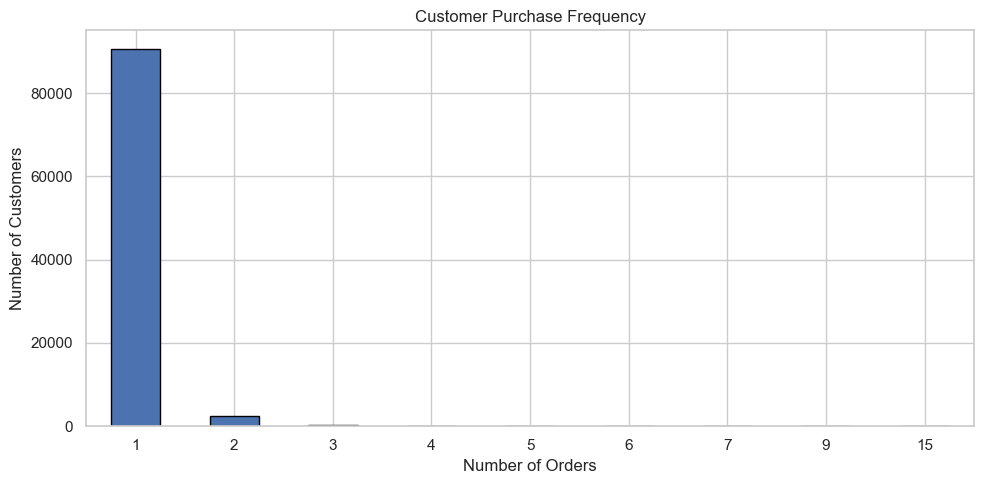

In [22]:
plt.figure(figsize=(10,5))

purchase_frequency.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Customer Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

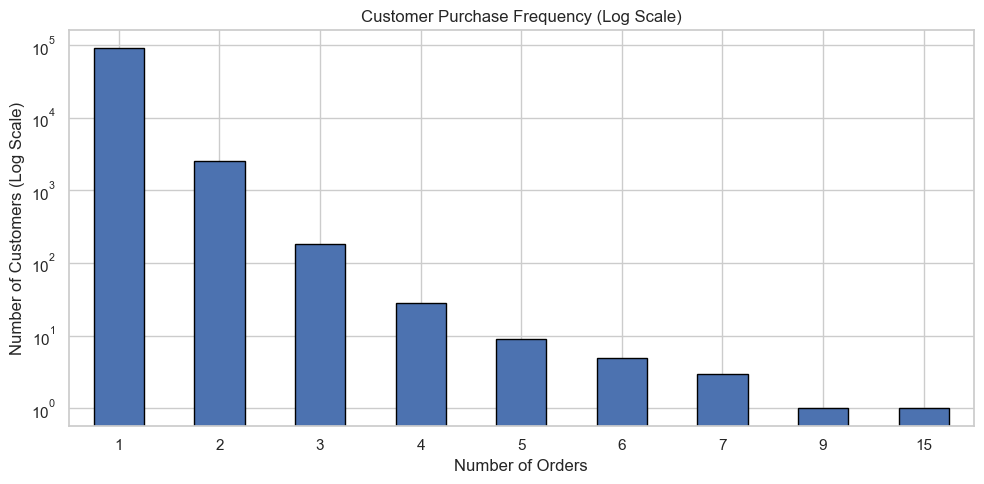

In [23]:
plt.figure(figsize=(10,5))

purchase_frequency.plot(
    kind='bar',
    edgecolor='black',
    logy=True
)

plt.title('Customer Purchase Frequency (Log Scale)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers (Log Scale)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##### Business Insight
Customer purchase frequency analysis revealed that customer retention is a major business challenge. Approximately **97%** of customers placed only one order, while only **3%** returned for multiple purchases. The purchase distribution was highly right-skewed, indicating that the business depended primarily on new customer acquisition rather than repeat customers.

#### Section 9 — Delivery Performance Analysis

In [24]:
delivery_df = fact_sales_df[['order_id',
                          'purchase_datetime',
                          'order_delivered_customer_date',
                          'order_estimated_delivery_date']].drop_duplicates()

delivery_df['delivery_days'] = (
    delivery_df['order_delivered_customer_date']
    - delivery_df['purchase_datetime']
).dt.days

delivery_df['estimated_days'] = (
    delivery_df['order_estimated_delivery_date']
    - delivery_df['purchase_datetime']
).dt.days

delivery_df['delay_days'] = (
    delivery_df['order_delivered_customer_date']
    - delivery_df['order_estimated_delivery_date']
).dt.days

delivery_df.head()

,order_id,purchase_datetime,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_days,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0


In [25]:
delivery_df[['delivery_days',
             'estimated_days',
             'delay_days']].describe()

,delivery_days,estimated_days,delay_days
count,96469.000000,96477.000000,96469.000000
mean,12.093170,23.372814,-11.876385
std,9.550476,8.758166,10.180991
min,0.000000,2.000000,-147.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,188.000000


In [26]:
delivery_df['delivery_status'] = np.where(
    delivery_df['delay_days'] <= 0,
    'On Time',
    'Late'
)

delivery_summary = (
    delivery_df['delivery_status']
    .value_counts()
    .to_frame(name='orders')
)

delivery_summary['percentage'] = (
    delivery_summary['orders'] /
    delivery_summary['orders'].sum() * 100
).round(2)

delivery_summary

,orders,percentage
delivery_status,,
On Time,89936,93.22
Late,6541,6.78


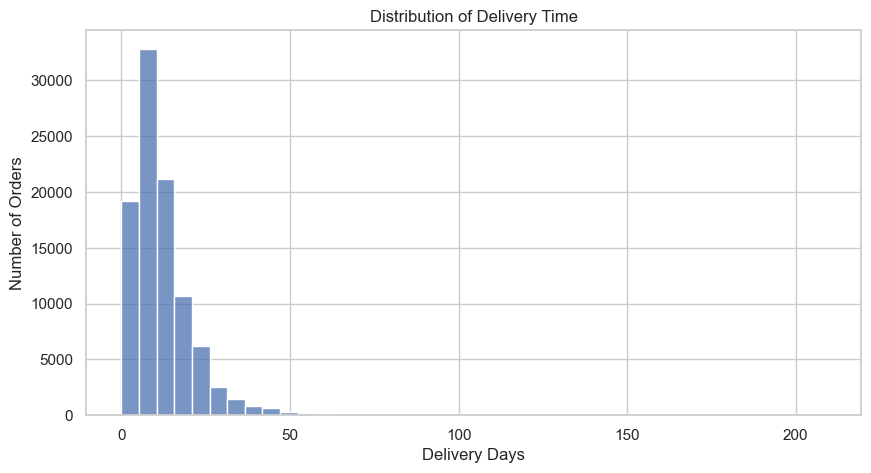

In [27]:
# Distribution of Delivery Time

plt.figure(figsize=(10,5))

sns.histplot(
    delivery_df['delivery_days'],
    bins=40
)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')

plt.show()

##### Business Insight
The logistics process is generally efficient, but a small number of orders experience unusually long shipping times that could negatively impact customer satisfaction.

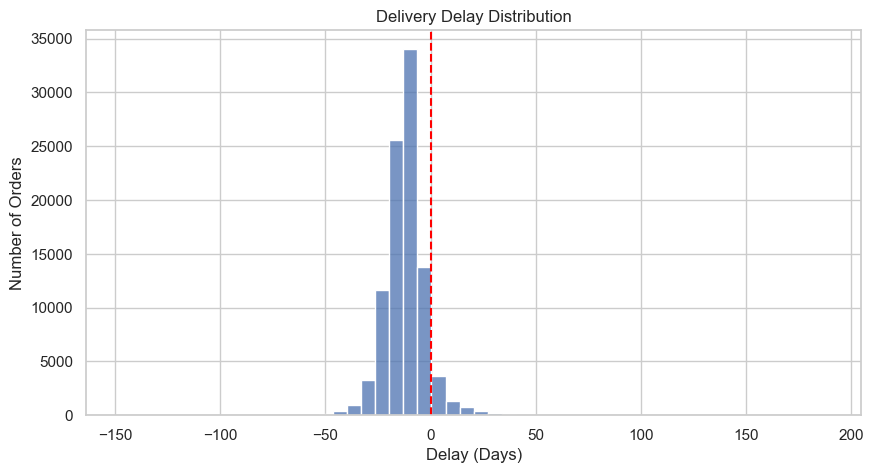

In [28]:
# Delivery Delay Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    delivery_df['delay_days'],
    bins=50
)

plt.axvline(0, color='red', linestyle='--')

plt.title('Delivery Delay Distribution')
plt.xlabel('Delay (Days)')
plt.ylabel('Number of Orders')

plt.show()

##### Business Insight
Orders are typically delivered nearly two weeks earlier than the promised delivery date, suggesting that estimated delivery dates are conservative.

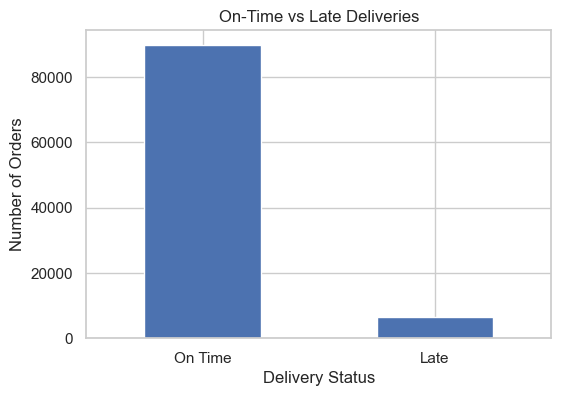

In [29]:
delivery_summary['orders'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('On-Time vs Late Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=0)

plt.show()

##### Business Insight
Over **93%** of orders reach customers on or before the promised delivery date, indicating strong logistics performance.

#### Section 10 — Payment Analysis

In [32]:
payment_counts = (
    fact_sales_df['payment_type']
    .value_counts()
    .reset_index()
)

payment_counts.columns = ['payment_type', 'orders']

payment_counts['percentage'] = (
    payment_counts['orders']
    / payment_counts['orders'].sum()
    * 100
).round(2)

payment_counts

,payment_type,orders,percentage
0,credit_card,82125,74.53
1,boleto,22362,20.29
2,"credit_card, voucher",2441,2.22
3,debit_card,1652,1.50
4,voucher,1613,1.46
5,"credit_card, debit_card",1,0.00


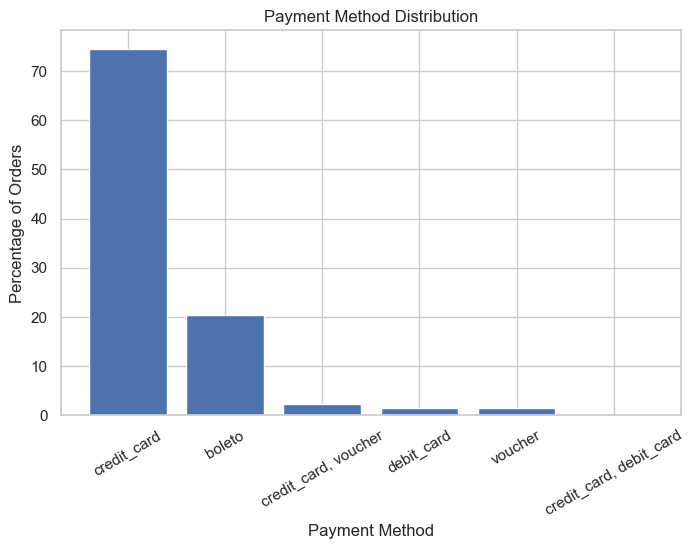

In [35]:
# Payment Method Distribution

plt.figure(figsize=(8,5))

plt.bar(
    payment_counts['payment_type'],
    payment_counts['percentage']
)

plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=30)

plt.show()

##### Business Insights
1. Credit Card dominates the platform with **82,125** orders **(74.53%)**.
2. Boleto is the second most popular payment method with **22,362** orders **(20.29%)**.
3. A very small number of customers **(2.22%)** combined Credit Card + Voucher in the same purchase.